In [2]:
#ASSIGNMENT 1
# FINANCIAL ECONOMETRICS — PROJECT 1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [3]:
np.random.seed(42)
dates = pd.date_range(start='2015-01-01', end='2024-12-31', freq='B')
n = len(dates)
n

2609

In [4]:
common_trend = np.cumsum(np.random.normal(0.0003, 0.01, n))
common_trend


array([0.00526714, 0.0041845 , 0.01096138, ..., 1.62353994, 1.60178428,
       1.61105495], shape=(2609,))

In [5]:
aapl = 110 * np.exp(common_trend * 1.2 + np.cumsum(np.random.normal(0.0001, 0.008, n)))
msft = 45  * np.exp(common_trend * 1.1 + np.cumsum(np.random.normal(0.0001, 0.007, n)))
googl= 530 * np.exp(common_trend * 1.0 + np.cumsum(np.random.normal(0.0001, 0.009, n)))

prices = pd.DataFrame({'AAPL': aapl, 'MSFT': msft, 'GOOGL': googl}, index=dates)

prices

,AAPL,MSFT,GOOGL
2015-01-01,111.843429,45.103464,531.793769
2015-01-02,112.293159,44.677744,532.186099
2015-01-05,112.195593,45.582482,530.342358
2015-01-06,114.133423,46.376875,537.759035
2015-01-07,113.859602,46.204689,540.324731
...,...,...,...
2024-12-25,659.537998,203.591401,4421.661528
2024-12-26,660.282933,203.670233,4427.831627
2024-12-27,658.461331,203.775217,4401.000109
2024-12-30,643.052726,200.606534,4316.458109


In [6]:
log_prices = np.log(prices)
returns = prices.pct_change().dropna()
log_returns = log_prices.diff().dropna()

print('Data loaded successfully!')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Observations: {len(prices)}')
print('\nDescriptive Statistics:')
print(prices.describe().round(2))

Data loaded successfully!
Date range: 2015-01-01 to 2024-12-31
Observations: 2609

Descriptive Statistics:
          AAPL     MSFT    GOOGL
count  2609.00  2609.00  2609.00
mean    340.86   101.96  2140.92
std     173.03    52.84  1259.57
min     105.12    34.91   471.24
25%     147.56    47.77   766.67
50%     348.37    92.53  2139.57
75%     484.66   153.47  3439.58
max     726.70   217.73  4681.75


In [7]:
# CHALLENGE 1: MULTICOLLINEARITY  DEMONSTRATION 

X_raw = returns[['MSFT', 'GOOGL']].copy()
X_raw['MSFT_GOOGL'] = X_raw['MSFT'] * X_raw['GOOGL'] 
y = returns['AAPL']
print(X_raw,
      y)


                MSFT     GOOGL    MSFT_GOOGL
2015-01-02 -0.009439  0.000738 -6.963403e-06
2015-01-05  0.020250 -0.003464 -7.015653e-05
2015-01-06  0.017428  0.013985  2.437197e-04
2015-01-07 -0.003713  0.004771 -1.771386e-05
2015-01-08 -0.008610  0.003844 -3.309185e-05
...              ...       ...           ...
2024-12-25 -0.009848  0.003412 -3.360069e-05
2024-12-26  0.000387  0.001395  5.403199e-07
2024-12-27  0.000515 -0.006060 -3.123553e-06
2024-12-30 -0.015550 -0.019210  2.987092e-04
2024-12-31  0.009935  0.011046  1.097407e-04

[2608 rows x 3 columns] 2015-01-02    0.004021
2015-01-05   -0.000869
2015-01-06    0.017272
2015-01-07   -0.002399
2015-01-08    0.002444
                ...   
2024-12-25   -0.003830
2024-12-26    0.001129
2024-12-27   -0.002759
2024-12-30   -0.023401
2024-12-31    0.007194
Freq: B, Name: AAPL, Length: 2608, dtype: float64


In [8]:
corr_matrix = X_raw.corr()
print('Correlation Matrix of Predictors:')
print(corr_matrix.round(4))

Correlation Matrix of Predictors:
              MSFT   GOOGL  MSFT_GOOGL
MSFT        1.0000  0.6180      0.1105
GOOGL       0.6180  1.0000      0.0858
MSFT_GOOGL  0.1105  0.0858      1.0000


In [9]:
X_vif = add_constant(X_raw)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_raw.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X_raw.shape[1])]
print('\nVariance Inflation Factors (VIF):')
print(vif_data.round(4))
print('\nRule of thumb: VIF > 10 = severe multicollinearity')


Variance Inflation Factors (VIF):
      Feature     VIF
0        MSFT  1.6266
1       GOOGL  1.6186
2  MSFT_GOOGL  1.0129

Rule of thumb: VIF > 10 = severe multicollinearity


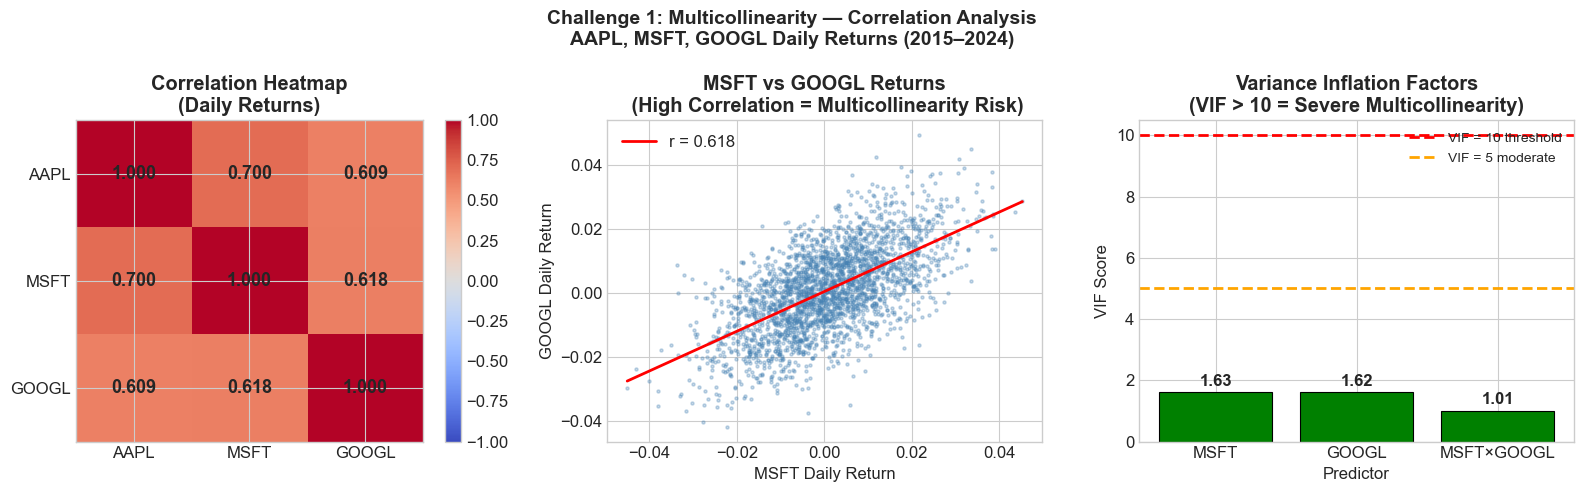

Figure saved.


In [10]:
# MULTICOLLINEARITY  DIAGRAM

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Challenge 1: Multicollinearity — Correlation Analysis\nAAPL, MSFT, GOOGL Daily Returns (2015–2024)',
             fontsize=14, fontweight='bold')

# Heatmap
import matplotlib.colors as mcolors
full_corr = returns.corr()
im = axes[0].imshow(full_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(full_corr.columns); axes[0].set_yticklabels(full_corr.columns)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{full_corr.iloc[i,j]:.3f}', ha='center', va='center', fontsize=13, fontweight='bold')
axes[0].set_title('Correlation Heatmap\n(Daily Returns)', fontweight='bold')
plt.colorbar(im, ax=axes[0])

# Scatter: MSFT vs GOOGL returns
axes[1].scatter(returns['MSFT'], returns['GOOGL'], alpha=0.3, s=5, color='steelblue')
m, b = np.polyfit(returns['MSFT'], returns['GOOGL'], 1)
x_line = np.linspace(returns['MSFT'].min(), returns['MSFT'].max(), 100)
axes[1].plot(x_line, m*x_line + b, 'r-', linewidth=2, label=f'r = {returns["MSFT"].corr(returns["GOOGL"]):.3f}')
axes[1].set_xlabel('MSFT Daily Return'); axes[1].set_ylabel('GOOGL Daily Return')
axes[1].set_title('MSFT vs GOOGL Returns\n (High Correlation = Multicollinearity Risk)', fontweight='bold')
axes[1].legend(fontsize=12)

# VIF bar chart
vif_labels = ['MSFT', 'GOOGL', 'MSFT×GOOGL']
vif_vals = vif_data['VIF'].values
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_vals]
bars = axes[2].bar(vif_labels, vif_vals, color=colors, edgecolor='black', linewidth=0.8)
axes[2].axhline(y=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 threshold')
axes[2].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5 moderate')
for bar, val in zip(bars, vif_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}',
                 ha='center', va='bottom', fontweight='bold')
axes[2].set_xlabel('Predictor'); axes[2].set_ylabel('VIF Score')
axes[2].set_title('Variance Inflation Factors\n(VIF > 10 = Severe Multicollinearity)', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()
print('Figure saved.')

In [11]:
 # SKEWNESS DEMONSTRATION

aapl_ret = returns['AAPL'].copy()
print(aapl_ret)

2015-01-02    0.004021
2015-01-05   -0.000869
2015-01-06    0.017272
2015-01-07   -0.002399
2015-01-08    0.002444
                ...   
2024-12-25   -0.003830
2024-12-26    0.001129
2024-12-27   -0.002759
2024-12-30   -0.023401
2024-12-31    0.007194
Freq: B, Name: AAPL, Length: 2608, dtype: float64


In [12]:
# Statistics
print('=== Skewness Analysis: AAPL Daily Returns ===')
print(f'Mean:              {aapl_ret.mean():.6f}')
print(f'Std Dev:           {aapl_ret.std():.6f}')
print(f'Skewness:          {aapl_ret.skew():.4f}')
print(f'Excess Kurtosis:   {aapl_ret.kurtosis():.4f}')

=== Skewness Analysis: AAPL Daily Returns ===
Mean:              0.000777
Std Dev:           0.014411
Skewness:          0.0832
Excess Kurtosis:   -0.0132


In [13]:
# Jarque-Bera test
jb_stat, jb_pval = stats.jarque_bera(aapl_ret)
print(f'\nJarque-Bera Statistic: {jb_stat:.4f}')
print(f'Jarque-Bera p-value:   {jb_pval:.6f}')
print(f'Conclusion: {"REJECT normality" if jb_pval < 0.05 else "FAIL to reject normality"} at 5% level')



Jarque-Bera Statistic: 3.0332
Jarque-Bera p-value:   0.219457
Conclusion: FAIL to reject normality at 5% level


In [14]:
# All three stocks
print('\n=== Skewness for All Stocks ===')
for col in returns.columns:
    sk = returns[col].skew()
    ku = returns[col].kurtosis()
    jb, p = stats.jarque_bera(returns[col])
    print(f'{col}: Skew={sk:.4f}, ExcessKurt={ku:.4f}, JB p-val={p:.4f}')


=== Skewness for All Stocks ===
AAPL: Skew=0.0832, ExcessKurt=-0.0132, JB p-val=0.2195
MSFT: Skew=0.0714, ExcessKurt=-0.0001, JB p-val=0.3310
GOOGL: Skew=-0.0023, ExcessKurt=0.0476, JB p-val=0.8938


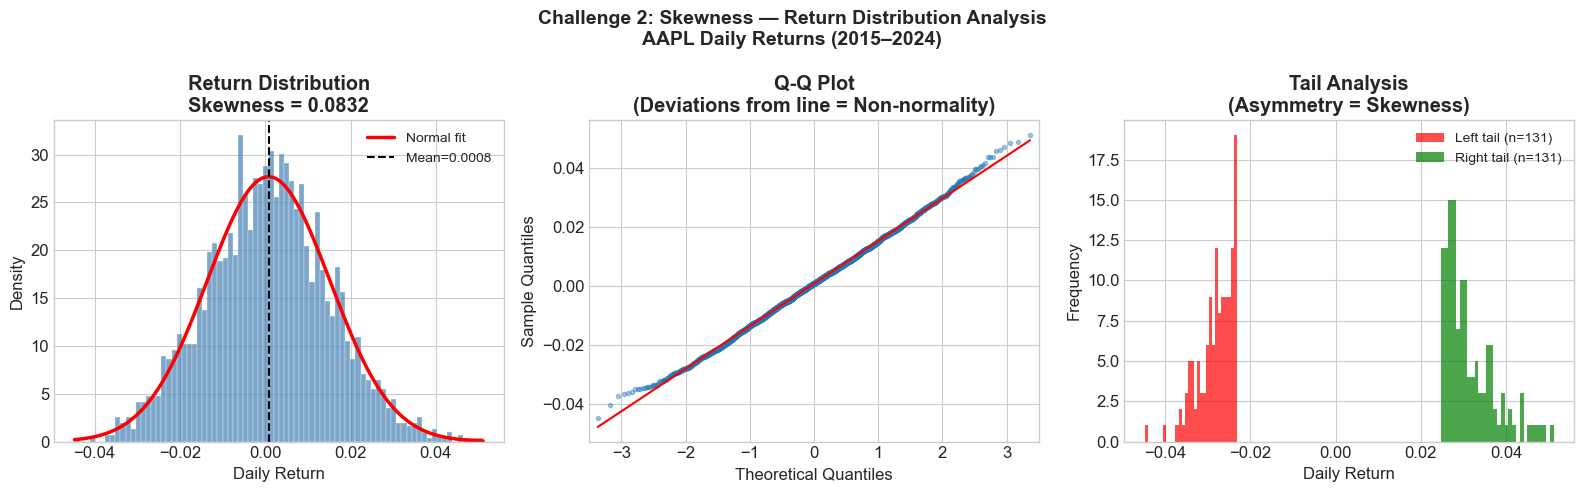

In [15]:
# SKEWNESS DIAGRAM

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Challenge 2: Skewness — Return Distribution Analysis\nAAPL Daily Returns (2015–2024)',
             fontsize=14, fontweight='bold')

# Histogram with normal overlay
aapl_ret = returns['AAPL']
axes[0].hist(aapl_ret, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.3)
x = np.linspace(aapl_ret.min(), aapl_ret.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, aapl_ret.mean(), aapl_ret.std()), 'r-', linewidth=2.5, label='Normal fit')
axes[0].axvline(aapl_ret.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={aapl_ret.mean():.4f}')
axes[0].set_xlabel('Daily Return'); axes[0].set_ylabel('Density')
axes[0].set_title(f'Return Distribution\nSkewness = {aapl_ret.skew():.4f}', fontweight='bold')
axes[0].legend(fontsize=10)

# QQ Plot
sm.qqplot(aapl_ret, line='s', ax=axes[1], alpha=0.4, markersize=3)
axes[1].set_title('Q-Q Plot\n(Deviations from line = Non-normality)', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles'); axes[1].set_ylabel('Sample Quantiles')

# Tail comparison
left_tail = aapl_ret[aapl_ret < aapl_ret.quantile(0.05)]
right_tail = aapl_ret[aapl_ret > aapl_ret.quantile(0.95)]
axes[2].hist(left_tail, bins=30, color='red', alpha=0.7, label=f'Left tail (n={len(left_tail)})')
axes[2].hist(right_tail, bins=30, color='green', alpha=0.7, label=f'Right tail (n={len(right_tail)})')
axes[2].set_xlabel('Daily Return'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Tail Analysis\n(Asymmetry = Skewness)', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# SENSITIVITY TO OUTLIERS DEMONSTRATION

aapl_ret = returns['AAPL']
msft_ret = returns['MSFT']

# Detect outliers using 3-sigma rule
threshold = 3 * aapl_ret.std()
outliers = aapl_ret[np.abs(aapl_ret - aapl_ret.mean()) > threshold]

print(f'=== Outlier Detection: AAPL Returns ===')
print(f'Mean: {aapl_ret.mean():.6f}')
print(f'Std Dev: {aapl_ret.std():.6f}')
print(f'3-sigma threshold: +/- {threshold:.4f}')
print(f'Number of outliers detected: {len(outliers)}')
print(f'Outlier dates and values:')
print(outliers.sort_values().round(4))



=== Outlier Detection: AAPL Returns ===
Mean: 0.000777
Std Dev: 0.014411
3-sigma threshold: +/- 0.0432
Number of outliers detected: 7
Outlier dates and values:
2019-03-22   -0.0448
2023-08-07    0.0456
2022-07-04    0.0460
2017-03-28    0.0470
2016-11-01    0.0483
2023-05-04    0.0487
2015-10-21    0.0511
Name: AAPL, dtype: float64


In [17]:
# Regression with and without outliers
X_all = add_constant(msft_ret)
model_all = OLS(aapl_ret, X_all).fit()

mask = np.abs(aapl_ret - aapl_ret.mean()) <= threshold
model_clean = OLS(aapl_ret[mask], add_constant(msft_ret[mask])).fit()

print(f'\n=== Regression Coefficients: With vs Without Outliers ===')
print(f'{"":20s} {"With Outliers":>15s} {"Without Outliers":>18s} {"Change":>10s}')
print('-'*65)
for param in ['const', 'MSFT']:
    v1 = model_all.params[param]
    v2 = model_clean.params[param]
    print(f'{param:20s} {v1:15.6f} {v2:18.6f} {abs(v1-v2):10.6f}')
print(f'\nR-squared (with outliers):    {model_all.rsquared:.4f}')
print(f'R-squared (without outliers): {model_clean.rsquared:.4f}')


=== Regression Coefficients: With vs Without Outliers ===
                       With Outliers   Without Outliers     Change
-----------------------------------------------------------------
const                       0.000268           0.000225   0.000043
MSFT                        0.769580           0.759084   0.010495

R-squared (with outliers):    0.4897
R-squared (without outliers): 0.4832


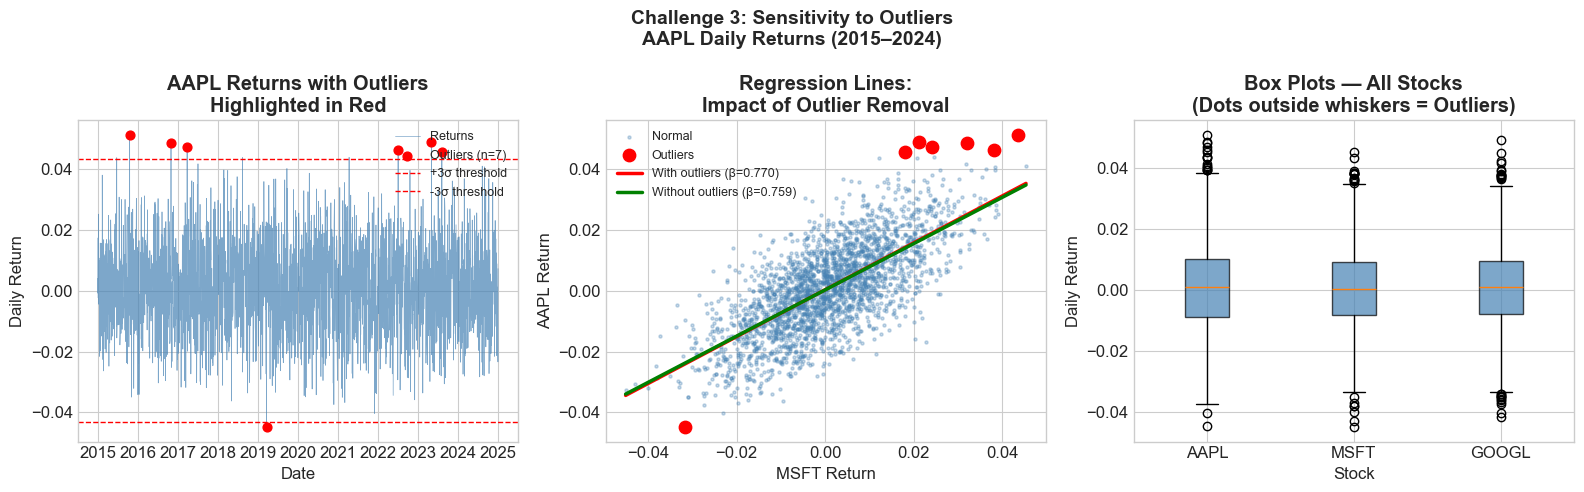

In [18]:
# SENSITIVITY TO OUTLIERS DIAGRAM

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Challenge 3: Sensitivity to Outliers\nAAPL Daily Returns (2015–2024)',
             fontsize=14, fontweight='bold')

# Time series with outliers highlighted
is_outlier = np.abs(aapl_ret - aapl_ret.mean()) > threshold
axes[0].plot(aapl_ret.index, aapl_ret, color='steelblue', linewidth=0.5, alpha=0.7, label='Returns')
axes[0].scatter(aapl_ret[is_outlier].index, aapl_ret[is_outlier], color='red', s=40, zorder=5, label=f'Outliers (n={is_outlier.sum()})')
axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1, label='+3σ threshold')
axes[0].axhline(-threshold, color='red', linestyle='--', linewidth=1, label='-3σ threshold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Daily Return')
axes[0].set_title('AAPL Returns with Outliers\nHighlighted in Red', fontweight='bold')
axes[0].legend(fontsize=9)

# Regression with vs without outliers
axes[1].scatter(msft_ret[~is_outlier], aapl_ret[~is_outlier], alpha=0.3, s=5, color='steelblue', label='Normal')
axes[1].scatter(msft_ret[is_outlier], aapl_ret[is_outlier], alpha=1.0, s=80, color='red', zorder=5, label='Outliers')
x_range = np.linspace(msft_ret.min(), msft_ret.max(), 100)
axes[1].plot(x_range, model_all.params['const'] + model_all.params['MSFT']*x_range,
             'r-', linewidth=2.5, label=f'With outliers (β={model_all.params["MSFT"]:.3f})')
axes[1].plot(x_range, model_clean.params['const'] + model_clean.params['MSFT']*x_range,
             'g-', linewidth=2.5, label=f'Without outliers (β={model_clean.params["MSFT"]:.3f})')
axes[1].set_xlabel('MSFT Return'); axes[1].set_ylabel('AAPL Return')
axes[1].set_title('Regression Lines:\nImpact of Outlier Removal', fontweight='bold')
axes[1].legend(fontsize=9)

# Box plot
bp = axes[2].boxplot([returns['AAPL'], returns['MSFT'], returns['GOOGL']],
                     labels=['AAPL', 'MSFT', 'GOOGL'], patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[2].set_xlabel('Stock'); axes[2].set_ylabel('Daily Return')
axes[2].set_title('Box Plots — All Stocks\n(Dots outside whiskers = Outliers)', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# OVERFITTING  DEMONSTRATION

# Train/test split — 80% train, 20% test
split = int(0.8 * len(returns))
train = returns.iloc[:split]
test  = returns.iloc[split:]

aapl_train = train['AAPL']
msft_train = train['MSFT']
aapl_test  = test['AAPL']
msft_test  = test['MSFT']

print('=== Overfitting: In-Sample vs Out-of-Sample Performance ===')
print(f'Training period: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} obs)')
print(f'Testing period:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} obs)')
print()

results = []
for degree in range(1, 8):
      
    X_train_poly = np.column_stack([msft_train**i for i in range(1, degree+1)])
    X_test_poly  = np.column_stack([msft_test**i  for i in range(1, degree+1)])
    
    model = OLS(aapl_train, add_constant(X_train_poly)).fit()
    
    pred_train = model.predict(add_constant(X_train_poly))
    pred_test  = model.predict(add_constant(X_test_poly))
    
    rmse_train = np.sqrt(np.mean((aapl_train - pred_train)**2))
    rmse_test  = np.sqrt(np.mean((aapl_test  - pred_test)**2))
    
    results.append({'Degree': degree, 'In-Sample R²': model.rsquared,
                    'AIC': model.aic, 'BIC': model.bic,
                    'Train RMSE': rmse_train, 'Test RMSE': rmse_test})

results_df = pd.DataFrame(results)
print(results_df.round(6).to_string(index=False))
print('\nNote: As degree increases, Train RMSE falls but Test RMSE rises= overfitting!')

=== Overfitting: In-Sample vs Out-of-Sample Performance ===
Training period: 2015-01-02 to 2022-12-30 (2086 obs)
Testing period:  2023-01-02 to 2024-12-31 (522 obs)

 Degree  In-Sample R²           AIC           BIC  Train RMSE  Test RMSE
      1      0.493631 -13169.444180 -13158.158172    0.010291   0.010303
      2      0.493633 -13167.450488 -13150.521478    0.010291   0.010303
      3      0.493721 -13165.815659 -13143.243645    0.010290   0.010309
      4      0.494016 -13165.028207 -13136.813188    0.010287   0.010285
      5      0.494029 -13163.083572 -13129.225550    0.010287   0.010283
      6      0.494096 -13161.361713 -13121.860688    0.010286   0.010294
      7      0.494383 -13160.542545 -13115.398515    0.010283   0.010313

Note: As degree increases, Train RMSE falls but Test RMSE rises= overfitting!


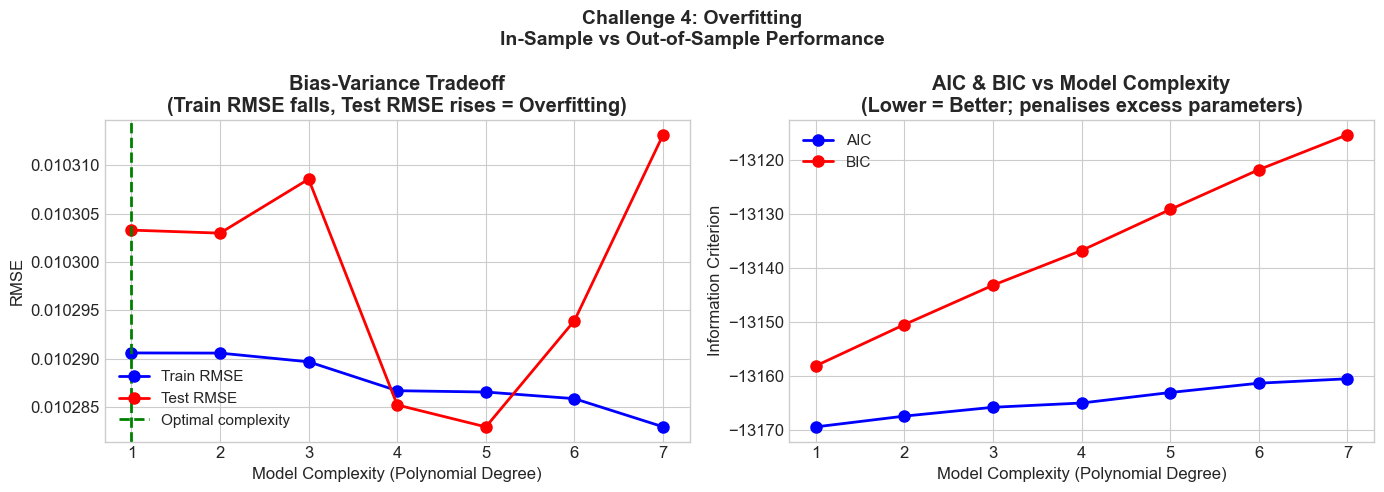

In [21]:
# OVERFITTING DIAGRAM

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Challenge 4: Overfitting\nIn-Sample vs Out-of-Sample Performance', fontsize=14, fontweight='bold')

degrees = results_df['Degree']
axes[0].plot(degrees, results_df['Train RMSE'], 'b-o', linewidth=2, markersize=8, label='Train RMSE')
axes[0].plot(degrees, results_df['Test RMSE'],  'r-o', linewidth=2, markersize=8, label='Test RMSE')
axes[0].axvline(x=1, color='green', linestyle='--', linewidth=2, label='Optimal complexity')
axes[0].set_xlabel('Model Complexity (Polynomial Degree)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Bias-Variance Tradeoff\n(Train RMSE falls, Test RMSE rises = Overfitting)', fontweight='bold')
axes[0].legend(fontsize=11)

axes[1].plot(degrees, results_df['AIC'], 'b-o', linewidth=2, markersize=8, label='AIC')
axes[1].plot(degrees, results_df['BIC'], 'r-o', linewidth=2, markersize=8, label='BIC')
axes[1].set_xlabel('Model Complexity (Polynomial Degree)')
axes[1].set_ylabel('Information Criterion')
axes[1].set_title('AIC & BIC vs Model Complexity\n(Lower = Better; penalises excess parameters)', fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()